In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')  
sns.set_palette('pastel')

In [5]:
# Loading Dataset
df = pd.read_csv("INvideos.csv")
print(df.shape)
print(df.columns)
print(df.head())

(37352, 16)
Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')
      video_id trending_date  \
0  kzwfHumJyYc      17.14.11   
1  zUZ1z7FwLc8      17.14.11   
2  10L1hZ9qa58      17.14.11   
3  N1vE8iiEg64      17.14.11   
4  kJzGH0PVQHQ      17.14.11   

                                               title    channel_title  \
0  Sharry Mann: Cute Munda ( Song Teaser) | Parmi...  Lokdhun Punjabi   
1  पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...          HJ NEWS   
2  Stylish Star Allu Arjun @ ChaySam Wedding Rece...             TFPC   
3                     Eruma Saani | Tamil vs English      Eruma Saani   
4  why Samantha became EMOTIONAL @ Samantha naga ...       Filmylooks   

   category_id              publish_time  \
0            1  2017

In [6]:
print("Rows:", df.shape[0], "Columns:", df.shape[1])
print("Columns List:", df.columns.tolist())
print(df.info())
print(df.head())
print(df.isnull().sum())

Rows: 37352 Columns: 16
Columns List: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37352 non-null  object
 1   trending_date           37352 non-null  object
 2   title                   37352 non-null  object
 3   channel_title           37352 non-null  object
 4   category_id             37352 non-null  int64 
 5   publish_time            37352 non-null  object
 6   tags                    37352 non-null  object
 7   views                   37352 non-null  int64 
 8   likes                   37352 non-null  int64 
 9   dislikes                37352 non-

In [7]:
df.drop_duplicates(inplace=True)
relevant_cols = ['title', 'channel_title', 'category_id', 'views', 'likes', 'dislikes', 'comment_count']
df = df[relevant_cols]
df.dropna(subset=relevant_cols, inplace=True)
df['title'] = df['title'].str.strip().str.title()
df['channel_title'] = df['channel_title'].str.strip().str.title()
df = df[df['views'] > 0]
print("After cleaning:", df.shape)


After cleaning: (33089, 7)


In [8]:
df['engagement_rate'] = ((df['likes'] + df['comment_count']) / df['views']) * 100

category_stats = df.groupby('category_id')[['views','likes','engagement_rate']].mean().reset_index()
category_stats = category_stats.sort_values(by='views', ascending=False)
print(category_stats.head())

    category_id         views         likes  engagement_rate
6            20  3.606369e+06  92729.618182         4.293810
15           30  3.191953e+06  40975.000000         1.735499
2            10  2.532352e+06  64721.544046         2.770522
0             1  2.237283e+06  39501.505810         2.140588
4            17  1.846151e+06  44077.128483         1.523497


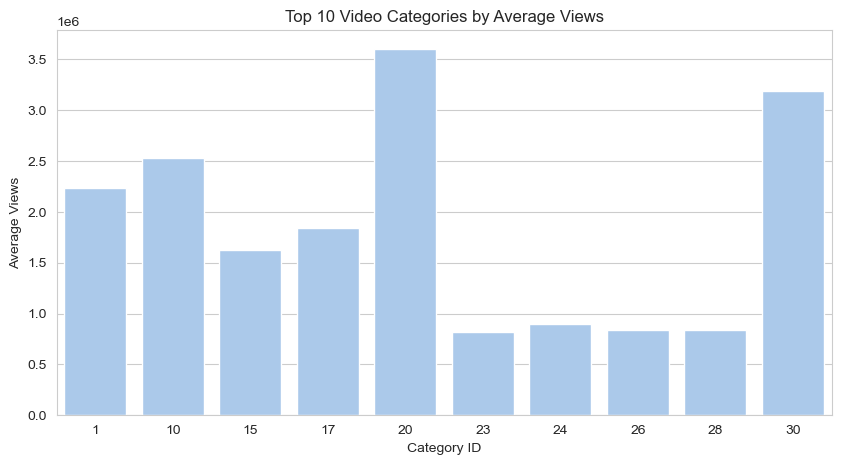

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(x='category_id', y='views', data=category_stats.head(10))
plt.title('Top 10 Video Categories by Average Views')
plt.xlabel('Category ID')
plt.ylabel('Average Views')
plt.show()

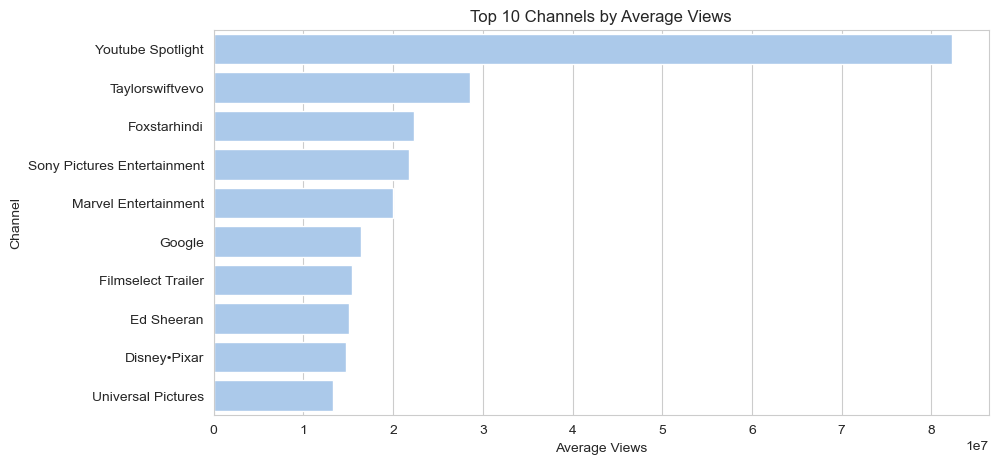

In [9]:
top_channels = df.groupby('channel_title')['views'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_channels.values, y=top_channels.index)
plt.title('Top 10 Channels by Average Views')
plt.xlabel('Average Views')
plt.ylabel('Channel')
plt.show()

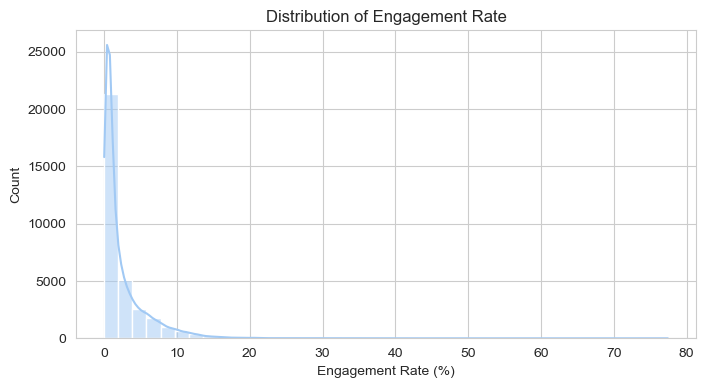

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['engagement_rate'], bins=40, kde=True)
plt.title('Distribution of Engagement Rate')
plt.xlabel('Engagement Rate (%)')
plt.show()

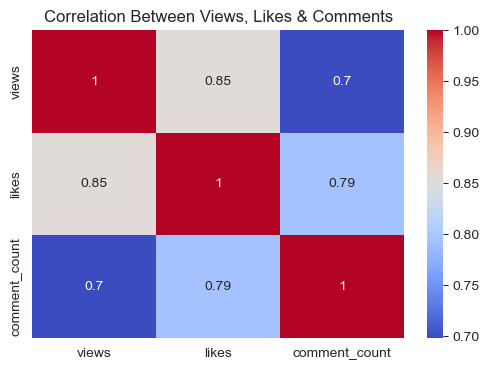

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['views','likes','comment_count']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Views, Likes & Comments')
plt.show()
